In [1]:
import torch
from utils import solve_riccati
import numpy as np
from network import ScoreNetwork
from utils import batched_jacobian, rollout, non_adapted_adjoint, train_phi_network
import matplotlib.pyplot as plt

In [2]:
import matplotlib

plt.rc('font', size = 14)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [3]:
T = 2.0  # End time
n = 2    # Dimension of state space
m = 2    # Dimension of Brownian motion
N = 2000 # Number of training samples
dt = 0.05  # Time step size
steps = int(T/dt)  # Number of time steps
noise_level = 1  # Noise level in the SDE
exp_num = 10 # Experiment number for saving results

In [4]:
def f(x, t, u_t=None):
    """
    Drift function of X_t for a linear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
    Returns:
        torch.Tensor: Drift vector. Shape (N, n)
    """
    A = torch.tensor([[0.0, 1.0], [-1.0, -0.5]])  # stable 
    # A = torch.tensor([[0.0, 1.0], [-1.0, 0.0]])  # marginal stable
    return x @ A.T

def g(x):
    """
    Diffusion function of X_t for a linear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
    Returns:
        torch.Tensor: Diffusion matrix. Shape (N, n, m)
    """
    B = torch.tensor([[1.0, 0.0], [0.0, 1.0]]) * noise_level
    B = B.unsqueeze(0).repeat(x.shape[0], 1, 1)
    return B

def lf(x):
    """
    Terminal cost function for a linear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
    Returns:
        torch.Tensor: Terminal cost. Shape (N,)
    """
    Q_f = torch.tensor([[1.0, 0.0], [0.0, 1.0]])
    return 0.5 * ((x @ Q_f) * x).sum(dim=1)

In [5]:
# Ground truth solution via Riccati equation
A = np.array([[0.0, 1.0], [-1.0, -0.5]])
# A = np.array([[0.0, 1.0], [-1.0, 0.0]])  # marginal stable
Q_f = np.array([[1.0, 0.0], [0.0, 1.0]])
G_ref = solve_riccati(A, Q_f, T, dt, dim=2)

In [6]:
phi_net = ScoreNetwork(input_dim=n+1, out_dim=n, hidden_dim=32, num_blocks=2)
phi_net.load_state_dict(torch.load('network/phi_network_linear_nl1_samplenum2000.pth',weights_only=True))
phi_net.eval()

ScoreNetwork(
  (time_emb): TimeFourierEmbedding(
    (proj): Sequential(
      (0): Linear(in_features=32, out_features=128, bias=True)
      (1): SiLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
    )
  )
  (inp): Linear(in_features=130, out_features=32, bias=True)
  (act): SiLU()
  (blocks): ModuleList(
    (0-1): 2 x ResBlock(
      (lin1): Linear(in_features=32, out_features=32, bias=True)
      (lin2): Linear(in_features=32, out_features=32, bias=True)
      (act): SiLU()
      (do): Identity()
      (ln): Identity()
    )
  )
  (out): Linear(in_features=32, out_features=2, bias=True)
)

Y_0 Mean square error with respect to noise level

In [7]:
## Adjoint matching dynamics
def adjoint_dyn(x, t):
    """
    Dynamics for the non-adapted adjoint process.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
        y (torch.Tensor): Costate vector. Shape (N, n)
        z (torch.Tensor): Second order term in BSDE. Shape (N, n, m)
        t (torch.Tensor): Current time. Shape (1,)
        u (torch.Tensor): Open-loop control inputs at each time step. Shape (steps, m)
    Returns:
        cost_term (torch.Tensor): Running cost term. Shape (N, n)
        lag_term_mat (torch.Tensor): Lagrange term y^T f_x. Shape (N, n, n)
    """
    A = torch.tensor([[0.0, 1.0], [-1.0, -0.5]])  # stable
    # A = torch.tensor([[0.0, 1.0], [-1.0, 0.0]])  # marginal stable
    cost_term = torch.zeros_like(x)  # shape (N, n)
    lag_term_mat = (A.T).repeat(x.shape[0], 1, 1)  # shape (N, n, n)
    return cost_term, lag_term_mat

def partial_lf(x):
    """
    Gradient of the terminal cost function for a linear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
    Returns:
        torch.Tensor: Gradient of the terminal cost. Shape (N, n)
    """
    Q_f = torch.tensor([[1.0, 0.0], [0.0, 1.0]])
    return x @ Q_f

In [ ]:
G0 = G_ref[:,:,0]
nl_list = [0, 0.5, 1, 2, 5] # noise levels for comparison
MSE_adjoint_list = torch.zeros((len(nl_list), exp_num))
MSE_TRBSDE_list = torch.zeros((len(nl_list), exp_num))
time_grid = torch.arange(0, steps+1) * dt
for exp in range(exp_num):
    for i, nl in enumerate(nl_list):
        X0_train = torch.randn((N, n))
        X0_test = torch.randn((N, n))
        Y0_test_gt = X0_test @ G0 # shape (N, n)
        def g(x):
            """
            Diffusion function of X_t for a linear system.
            Args:
                x (torch.Tensor): State vector. Shape (N, n)
            Returns:
                torch.Tensor: Diffusion matrix. Shape (N, n, m)
            """
            B = torch.tensor([[1.0, 0.0], [0.0, 1.0]]) * nl
            B = B.unsqueeze(0).repeat(x.shape[0], 1, 1)
            return B
        
        phi_adjoint = ScoreNetwork(input_dim=n+1, out_dim=n, hidden_dim=32, num_blocks=2)
        phi_adjoint.load_state_dict(torch.load(f'network/ad_phi_network_linear_nl{nl}_samplenum2000_stable_exp{exp+1}in{exp_num}_kf10.pth',weights_only=True))
        Y0_adjoint_test = phi_adjoint(X0_test, torch.tensor(0.0).repeat(X0_test.shape[0], 1)).detach()

        ## TR-BSDE method
        phi_net.load_state_dict(torch.load(f'network/tr_phi_network_linear_nl{nl}_samplenum2000_stable_exp{exp+1}in{exp_num}_kf10.pth',weights_only=True))
        theta_phi = X0_test.clone().detach()
        Y0_TRBSDE = phi_net(theta_phi, torch.tensor(0.0).repeat(theta_phi.shape[0], 1)).detach()


        ## Compute MSE
        MSE_adjoint = ((Y0_adjoint_test - Y0_test_gt)**2).sum(dim=1).mean().item()
        MSE_TRBSDE = ((Y0_TRBSDE - Y0_test_gt)**2).sum(dim=1).mean().item()
        MSE_adjoint_list[i, exp] = MSE_adjoint
        MSE_TRBSDE_list[i, exp] = MSE_TRBSDE




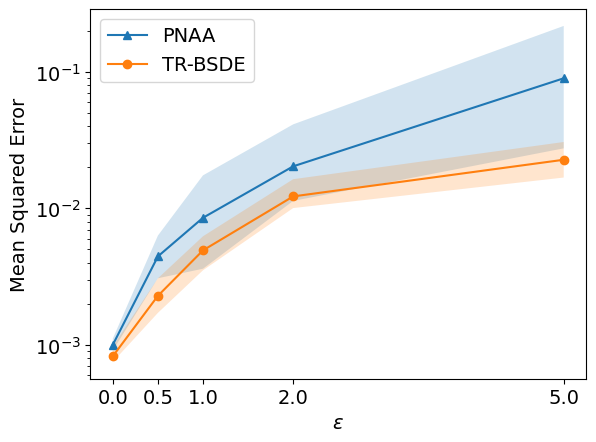

In [ ]:
plt.figure()
plt.plot(nl_list, MSE_adjoint_list.mean(dim=1).numpy(), label="PNAA", marker='^')
plt.fill_between(nl_list, MSE_adjoint_list.min(dim=1).values.numpy(), MSE_adjoint_list.max(dim=1).values.numpy(), alpha=0.2)
plt.plot(nl_list, MSE_TRBSDE_list.mean(dim=1).numpy(), label="TR-BSDE", marker='o')
plt.fill_between(nl_list, MSE_TRBSDE_list.min(dim=1).values.numpy(), MSE_TRBSDE_list.max(dim=1).values.numpy(), alpha=0.2)
plt.yscale("log")
plt.xticks(nl_list)
plt.xlabel(r"$\epsilon$")
plt.ylabel("Mean Squared Error")
plt.legend(loc='upper left')
# plt.show()
plt.savefig("figs/stable_linear_example_trainphi_mse_nl_expnum10both_kf10.pdf", bbox_inches='tight')